# <font color=' palegreen'>Data Science CA1</font>

<font color='palegreen'>Aidin Kazemi: 810101561</font>

<font color='palegreen'>Ali Zilouchi: 810101560</font>

<font color='palegreen'>Paria Pasehvarz: 810101393</font>

##<font color='orange'>**Sampling**</font>



First, we import necessary modules.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, wasserstein_distance, ks_2samp

np.random.seed(2)
print("hello")

Then we set hyper parameters and create the grid.

In [ ]:
mean = np.array([-5, 5])
cov = 5 * np.eye(2)

x = np.linspace(-15, 15, 30)
y = np.linspace(-15, 15, 30)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

We create the multivariate normal distribution.

In [ ]:
rv = multivariate_normal(mean, cov)

In this part we plot our normal distribution.

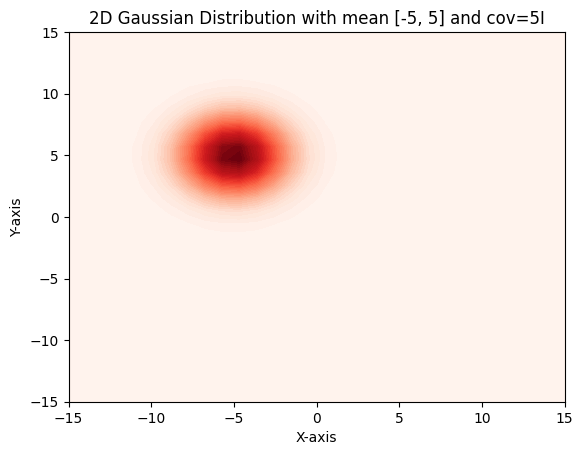

In [ ]:
plt.contourf(X, Y, rv.pdf(pos), cmap='Reds', levels=50)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('2D Gaussian Distribution with mean [-5, 5] and cov=5I')

plt.show()

Here we calculate score function according to equation below:
$$∇_x log(p(x)) = -Σ^{-1}(x- μ)$$

In [ ]:
cov_inv = np.linalg.inv(cov)

def score_function(x, mean, cov_inv):
    return -np.dot(cov_inv, (x - mean))

We calculate the score function borders for grid.

In [ ]:
U, V = np.zeros_like(X), np.zeros_like(Y)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x_point = np.array([X[i, j], Y[i, j]])
        score = score_function(x_point, mean, cov_inv)
        U[i, j], V[i, j] = score

To check our score fnuction, we plot it.

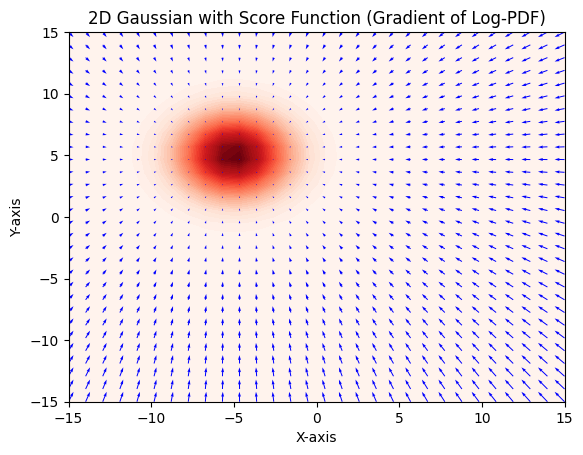

In [ ]:
plt.contourf(X, Y, rv.pdf(pos), cmap='Reds', levels=50)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('2D Gaussian with Score Function (Gradient of Log-PDF)')

plt.quiver(X, Y, U, V, color='blue', scale=200, width=0.002, headwidth=3)

plt.show()

Now we define a function for running lavengin dynamics and storing trajectory according to formula below:
$$X_{t+1}=X_{t} + ϵS_Θ(X_t)+\sqrt{2ϵ}Z_t$$

In [ ]:
def langevin_dynamics(initial_points, score_func, n_steps=100, step_size=0.1):
    n_samples, n_dims = initial_points.shape
    trajectories = np.zeros((n_steps + 1, n_samples, n_dims))
    x = initial_points.copy()
    trajectories[0] = x.copy()

    for t in range(n_steps):
        score = np.array([score_func(x[i],mean,cov_inv) for i in range(n_samples)])
        noise = np.random.randn(n_samples, n_dims) * np.sqrt(2 * step_size)
        x += step_size * score + noise

        trajectories[t+1] = x.copy()

    return x, trajectories

We plot trajectory for a point to check process of the algorithm.

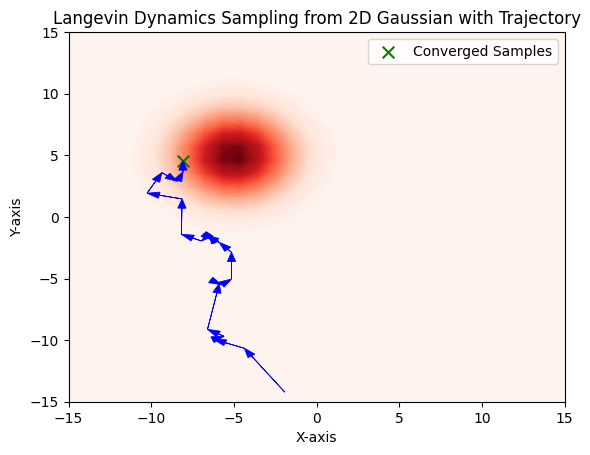

In [ ]:
np.random.seed(2)

initial_points = np.random.uniform(low=[-15, -15], high=[15, 15], size=(1, 2))
samples, trajectories = langevin_dynamics(initial_points, score_function, n_steps=20, step_size=0.5)

plt.contourf(X, Y, rv.pdf(pos), cmap='Reds', levels=50)

plt.scatter(samples[:, 0], samples[:, 1], c='green', marker='x', s=70, label='Converged Samples')

for i in range(0, len(trajectories)-1):
    dx = trajectories[i+1, 0, 0] - trajectories[i, 0, 0]
    dy = trajectories[i+1, 0, 1] - trajectories[i, 0, 1]
    plt.arrow(trajectories[i, 0, 0], trajectories[i, 0, 1], dx, dy,
              shape='full', lw=0.6, length_includes_head=True, head_width=0.5, color='blue')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Langevin Dynamics Sampling from 2D Gaussian with Trajectory')
plt.legend()
plt.show()

Here we take 1000 samples using our lavengin dynamic function and numpy pre-prepared method and plot them.

As you can see at below they're very similar.

* Note that we changed hyper parameters compared to before to get a better sampling.

Text(0.5, 1.0, 'Samples from Lavengin')

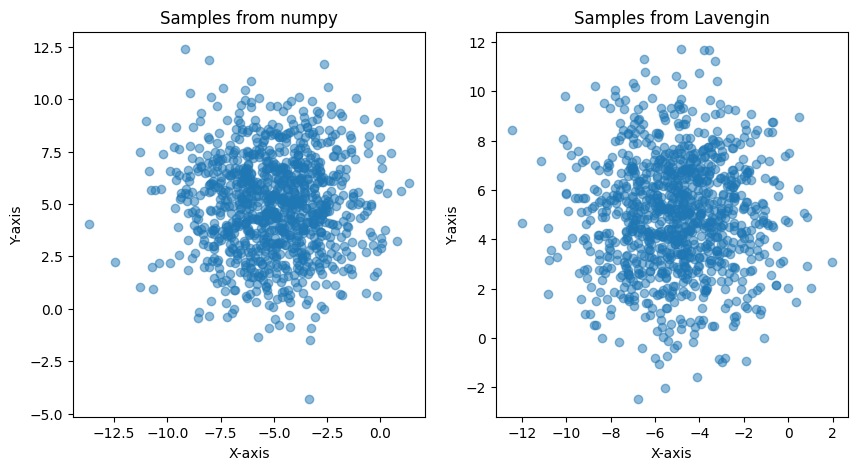

In [ ]:
np.random.seed(2)

initial_points = np.random.uniform(low=[-15, -15], high=[15, 15], size=(1000, 2))
langevin_samples, _ = langevin_dynamics(initial_points, score_function, n_steps=500, step_size=0.1)

np_samples = np.random.multivariate_normal(mean, cov, size=1000)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(np_samples[:, 0], np_samples[:, 1], alpha=0.5)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Samples from numpy')

plt.subplot(1, 2, 2)
plt.scatter(langevin_samples[:, 0], langevin_samples[:, 1], alpha=0.5)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Samples from Lavengin')

For other ways of comparsian, we use some ready tools from scipy module and compare mean and covariance, in below.

As you can see for proper hyperparameters, our results are very close.

In [ ]:
print("\n=== Mean Comparison ===")
print(f"Numpy Mean:     {np.mean(np_samples, axis=0)}")
print(f"Langevin Mean:     {np.mean(langevin_samples, axis=0)}")

print("\n=== Covariance Comparison ===")
print(f"Numpy Cov:\n {np.cov(np_samples.T)}")
print(f"Langevin Cov:\n {np.cov(langevin_samples.T)}")

print("\n=== Wasserstein Distance ===")
w_x = wasserstein_distance(np_samples[:, 0], langevin_samples[:, 0])
w_y = wasserstein_distance(np_samples[:, 1], langevin_samples[:, 1])
print(f"X-axis: {w_x:.3f}, Y-axis: {w_y:.3f} (Lower = Better)")

print("\n=== Kolmogorov-Smirnov Test ===")
ks_x = ks_2samp(np_samples[:, 0], langevin_samples[:, 0])
ks_y = ks_2samp(np_samples[:, 1], langevin_samples[:, 1])
print(f"X-axis: p-value={ks_x.pvalue:.3f}, Y-axis: p-value={ks_y.pvalue:.3f} (p > 0.05 → Similar)")


=== Mean Comparison ===
Numpy Mean:     [-5.01902854  4.94164216]
Langevin Mean:     [-5.02105186  4.97221474]

=== Covariance Comparison ===
Numpy Cov:
 [[ 4.90454733 -0.06307885]
 [-0.06307885  5.49824145]]
Langevin Cov:
 [[ 4.8521261  -0.02752053]
 [-0.02752053  5.36293817]]

=== Wasserstein Distance ===
X-axis: 0.078, Y-axis: 0.070 (Lower = Better)

=== Kolmogorov-Smirnov Test ===
X-axis: p-value=0.723, Y-axis: p-value=0.914 (p > 0.05 → Similar)


## <font color='orange'>**Bonus**</font>



### Bonus Question Recap

**Question:**  
For a mixture of Gaussians defined as  
$$
p(x) = \alpha\, \mathcal{N}(x; \mu_1, \Sigma_1) + (1-\alpha)\, \mathcal{N}(x; \mu_2, \Sigma_2)
$$  
with $0 < \alpha < 1$, can we use the Langevin dynamics algorithm to obtain proper samples? Justify your answer.

---

### Answer

#### 1. The Gaussian Density Function

A $d$-dimensional Gaussian density is given by:
$$
\mathcal{N}(x; \mu, \Sigma) = \frac{1}{\sqrt{(2\pi)^d |\Sigma|}} \exp\!\left(-\frac{1}{2}(x-\mu)^T \Sigma^{-1}(x-\mu)\right)
$$

- **Normalization:**  
  The constant $\frac{1}{\sqrt{(2\pi)^d |\Sigma|}}$ ensures the total probability integrates to 1.  
- **Exponential Term:**  
  The term $-\frac{1}{2}(x-\mu)^T \Sigma^{-1}(x-\mu)$ is the quadratic form (or Mahalanobis distance) which penalizes points far from the mean $\mu$. This is crucial for understanding how the density decreases as $x$ deviates from $\mu$.

Taking the natural logarithm of the Gaussian density, we have:
$$
\log \mathcal{N}(x; \mu, \Sigma) = -\frac{d}{2}\log(2\pi) - \frac{1}{2}\log |\Sigma| - \frac{1}{2}(x-\mu)^T \Sigma^{-1}(x-\mu)
$$

- **Explanation:**  
  The constant terms $-\frac{d}{2}\log(2\pi)$ and $-\frac{1}{2}\log |\Sigma|$ do not depend on $x$, so the variability of the log-density with respect to $x$ is governed entirely by the quadratic term. This quadratic structure makes the gradient (or score function) linear in $x$.

---

#### 2. Gradient (Score Function) for a Single Gaussian

The score function for a probability density $p(x)$ is defined as:
$$
\nabla_x \log p(x) = \frac{\nabla_x p(x)}{p(x)}
$$

For a Gaussian, using the log-density derived above:
$$
\nabla_x \log \mathcal{N}(x; \mu, \Sigma) = -\Sigma^{-1}(x-\mu)
$$

- **Interpretation:**  
  This gradient points in the direction of increasing probability density. Notice that the term $-\Sigma^{-1}(x-\mu)$ indicates a “pull” towards the mean $\mu$, with the strength of the pull modulated by $\Sigma^{-1}$. A larger difference $(x-\mu)$ results in a stronger gradient signal.

---

#### 3. Score Function for a Mixture of Gaussians

For the mixture,
$$
p(x) = \alpha\, \mathcal{N}(x; \mu_1, \Sigma_1) + (1-\alpha)\, \mathcal{N}(x; \mu_2, \Sigma_2),
$$  
each Gaussian component contributes to the overall density. To compute the score function, we differentiate $p(x)$ and then divide by $p(x)$:
$$
\nabla_x \log p(x) = \frac{\alpha\, \nabla_x \mathcal{N}(x; \mu_1, \Sigma_1) + (1-\alpha)\, \nabla_x \mathcal{N}(x; \mu_2, \Sigma_2)}{\alpha\, \mathcal{N}(x; \mu_1, \Sigma_1) + (1-\alpha)\, \mathcal{N}(x; \mu_2, \Sigma_2)}
$$

Since for each component we have:
$$
\nabla_x \mathcal{N}(x; \mu, \Sigma) = \mathcal{N}(x; \mu, \Sigma) \left[-\Sigma^{-1}(x-\mu)\right],
$$  
the score function becomes:
$$
\nabla_x \log p(x) = \frac{-\alpha\, \mathcal{N}(x; \mu_1, \Sigma_1)\Sigma_1^{-1}(x-\mu_1) - (1-\alpha)\, \mathcal{N}(x; \mu_2, \Sigma_2)\Sigma_2^{-1}(x-\mu_2)}{\alpha\, \mathcal{N}(x; \mu_1, \Sigma_1) + (1-\alpha)\, \mathcal{N}(x; \mu_2, \Sigma_2)}
$$

- **Explanation:**  
  This equation is a weighted average of the individual gradients. In regions where one Gaussian dominates, its corresponding term will have a larger weight, and the score will be close to the gradient of that component alone. However, near the boundaries between modes, the contributions mix, potentially leading to shallower gradients. This complexity is at the heart of the challenges in sampling multimodal distributions.

---

#### 4. Langevin Dynamics Update Equation

The Langevin dynamics algorithm uses the score function to update the state:
$$
x_{t+1} = x_t + \epsilon\, \nabla_x \log p(x_t) + \sqrt{2\epsilon}\, \eta_t,
$$  
where:
- $\epsilon$ is the step size,
- $\eta_t \sim \mathcal{N}(0, I)$ is Gaussian noise.

- **Deterministic Term ($\epsilon\, \nabla_x \log p(x_t)$):**  
  This term nudges the current sample $x_t$ towards regions of higher probability by following the gradient. For a mixture, it directs the sample based on the local balance of the two components.
  
- **Stochastic Term ($\sqrt{2\epsilon}\, \eta_t$):**  
  The noise term helps to explore the distribution by allowing random jumps. The scaling by $\sqrt{2\epsilon}$ ensures that the overall variance introduced by the noise is consistent with the step size, balancing exploration and stability.

- **Balancing Act:**  
  If $\epsilon$ is too small, the deterministic movement is weak and the noise does not allow for significant exploration, especially when trapped in a single mode. If $\epsilon$ is too large, the updates might overshoot and become unstable. In multimodal distributions, careful tuning is required to ensure that the algorithm can traverse low-density regions between modes.

---

### Conclusion and Practical Implications

**Theoretical Possibility vs. Practical Implementation:**

- **In Principle:**  
  Because Langevin dynamics uses the gradient of the log-density, it can, in theory, sample from any distribution—including mixtures of Gaussians. The equations show that if the score function is perfectly computed and the algorithm is run for a sufficiently long time, the samples would eventually represent the full mixture.

- **In Practice:**  
  The mixture's multimodality introduces challenges:
  - **Mode Trapping:**  
    The weighted score function may not provide a strong enough push to move between modes, causing the algorithm to get trapped in one region.
  - **Parameter Sensitivity:**  
    The step size $\epsilon$ and noise scaling are critical; poor tuning can lead to inefficient exploration.
  - **Adaptive Strategies Needed:**  
    Techniques such as adaptive step sizes, tempering, or running multiple parallel chains can help mitigate these issues and promote better mixing.

Thus, while the theoretical framework supports the use of Langevin dynamics for a mixture of Gaussians, the practical application requires careful consideration of these factors to achieve proper sampling.